In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import time

from sklearn.model_selection import StratifiedKFold, cross_val_score, RandomizedSearchCV

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    precision_recall_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

In [2]:
results_df = pd.read_csv(
    "../data/processed/ml_model_comparison.csv"
)

results_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,Training_Time,Prediction_Time
0,Decision Tree,0.736693,0.503876,0.521390,0.512484,0.667710,0.389757,0.179898,0.018361
1,XGBoost,0.799148,0.653199,0.518717,0.578241,0.844127,0.650283,0.697680,0.077227
2,KNN,0.776437,0.589666,0.518717,0.551920,0.788355,0.532609,0.012687,0.300129
3,Logistic Regression,0.799148,0.656357,0.510695,0.574436,0.843362,0.639736,0.591665,0.036410
4,Random Forest,0.781405,0.605096,0.508021,0.552326,0.822318,0.611618,1.976031,0.305828
5,Gradient Boosting,0.801278,0.666667,0.502674,0.573171,0.842478,0.651429,2.503611,0.041640


In [3]:
results_df = results_df.sort_values(
    by="ROC_AUC",
    ascending=False
).reset_index(drop=True)

results_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,Training_Time,Prediction_Time
0,XGBoost,0.799148,0.653199,0.518717,0.578241,0.844127,0.650283,0.697680,0.077227
1,Logistic Regression,0.799148,0.656357,0.510695,0.574436,0.843362,0.639736,0.591665,0.036410
2,Gradient Boosting,0.801278,0.666667,0.502674,0.573171,0.842478,0.651429,2.503611,0.041640
3,Random Forest,0.781405,0.605096,0.508021,0.552326,0.822318,0.611618,1.976031,0.305828
4,KNN,0.776437,0.589666,0.518717,0.551920,0.788355,0.532609,0.012687,0.300129
5,Decision Tree,0.736693,0.503876,0.521390,0.512484,0.667710,0.389757,0.179898,0.018361


In [4]:
best_model_name = results_df.loc[0, "Model"]

print("Best model from Phase 6:", best_model_name)

Best model from Phase 6: XGBoost


In [5]:
X_train = pd.read_csv(
    "../data/processed/ml_X_train_final.csv"
)

X_test = pd.read_csv(
    "../data/processed/ml_X_test_final.csv"
)

y_train = pd.read_csv(
    "../data/processed/ml_y_train.csv"
).squeeze()

y_test = pd.read_csv(
    "../data/processed/ml_y_test.csv"
).squeeze()

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5634, 53)
X_test: (1409, 53)
y_train: (5634,)
y_test: (1409,)


In [6]:
logistic_model = joblib.load(
    "../models/Logistic_Regression.pkl"
)

decision_tree_model = joblib.load(
    "../models/Decision_Tree.pkl"
)

knn_model = joblib.load(
    "../models/KNN.pkl"
)

random_forest_model = joblib.load(
    "../models/Random_Forest.pkl"
)

gradient_boosting_model = joblib.load(
    "../models/Gradient_Boosting.pkl"
)

xgboost_model = joblib.load(
    "../models/XGBoost.pkl"
)

In [7]:
def calculate_metrics(
    model_name,
    y_true,
    y_pred,
    y_probability
):
    
    accuracy = accuracy_score(
        y_true,
        y_pred
    )
    
    precision = precision_score(
        y_true,
        y_pred
    )
    
    recall = recall_score(
        y_true,
        y_pred
    )
    
    f1 = f1_score(
        y_true,
        y_pred
    )
    
    roc_auc = roc_auc_score(
        y_true,
        y_probability
    )
    
    pr_auc = average_precision_score(
        y_true,
        y_probability
    )
    
    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc
    }

In [9]:
# Baseline evaluation

logistic_pred = logistic_model.predict(X_test)

logistic_probability = logistic_model.predict_proba(
    X_test
)[:, 1]

logistic_metrics = calculate_metrics(
    "Logistic Regression",
    y_test,
    logistic_pred,
    logistic_probability
)

logistic_metrics

{'Model': 'Logistic Regression',
 'Accuracy': 0.7991483321504613,
 'Precision': 0.6563573883161512,
 'Recall': 0.5106951871657754,
 'F1': 0.5744360902255639,
 'ROC-AUC': 0.8433620088351547,
 'PR-AUC': 0.6397360323542194}

In [10]:
# Random Forest

rf_pred = random_forest_model.predict(X_test)

rf_probability = random_forest_model.predict_proba(
    X_test
)[:, 1]

rf_metrics = calculate_metrics(
    "Random Forest",
    y_test,
    rf_pred,
    rf_probability
)

rf_metrics

{'Model': 'Random Forest',
 'Accuracy': 0.7814052519517388,
 'Precision': 0.6050955414012739,
 'Recall': 0.5080213903743316,
 'F1': 0.5523255813953488,
 'ROC-AUC': 0.8223178072282933,
 'PR-AUC': 0.611617645793824}

In [11]:
# XGBoost

xgb_pred = xgboost_model.predict(X_test)

xgb_probability = xgboost_model.predict_proba(
    X_test
)[:, 1]

xgb_metrics = calculate_metrics(
    "XGBoost",
    y_test,
    xgb_pred,
    xgb_probability
)

xgb_metrics

{'Model': 'XGBoost',
 'Accuracy': 0.7991483321504613,
 'Precision': 0.6531986531986532,
 'Recall': 0.5187165775401069,
 'F1': 0.5782414307004471,
 'ROC-AUC': 0.8441266888837221,
 'PR-AUC': 0.6502828402694363}

In [12]:
baseline_results = pd.DataFrame([
    logistic_metrics,
    rf_metrics,
    xgb_metrics
])

baseline_results

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.799148,0.656357,0.510695,0.574436,0.843362,0.639736
1,Random Forest,0.781405,0.605096,0.508021,0.552326,0.822318,0.611618
2,XGBoost,0.799148,0.653199,0.518717,0.578241,0.844127,0.650283


In [14]:
baseline_results = baseline_results.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

baseline_results

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,XGBoost,0.799148,0.653199,0.518717,0.578241,0.844127,0.650283
1,Logistic Regression,0.799148,0.656357,0.510695,0.574436,0.843362,0.639736
2,Random Forest,0.781405,0.605096,0.508021,0.552326,0.822318,0.611618


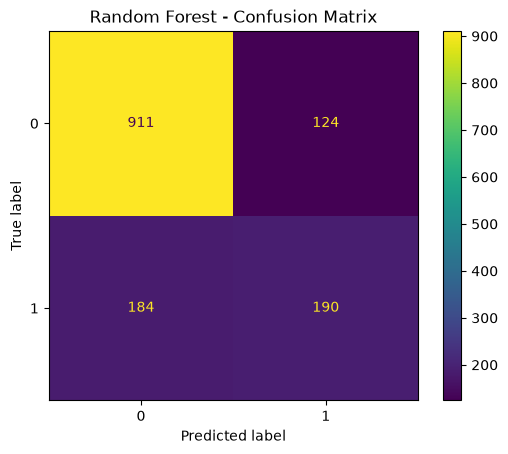

In [15]:
cm_rf = confusion_matrix(
    y_test,
    rf_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf
)

disp.plot()

plt.title("Random Forest - Confusion Matrix")
plt.show()

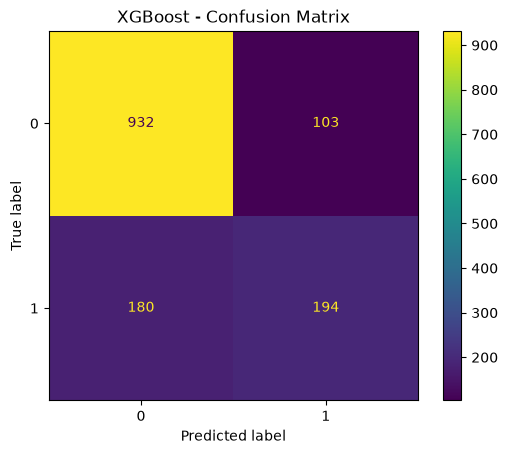

In [16]:
cm_xgb = confusion_matrix(
    y_test,
    xgb_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_xgb
)

disp.plot()

plt.title("XGBoost - Confusion Matrix")
plt.show()

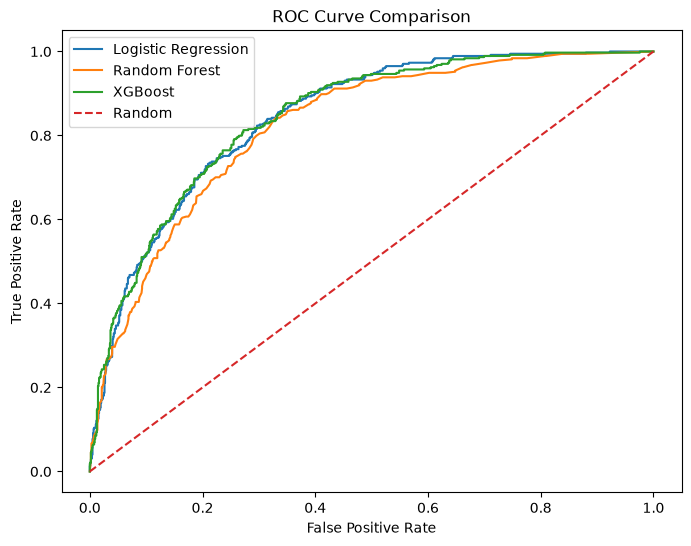

In [17]:
fpr_logistic, tpr_logistic, _ = roc_curve(
    y_test,
    logistic_probability
)

fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    rf_probability
)

fpr_xgb, tpr_xgb, _ = roc_curve(
    y_test,
    xgb_probability
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_logistic,
    tpr_logistic,
    label="Logistic Regression"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label="Random Forest"
)

plt.plot(
    fpr_xgb,
    tpr_xgb,
    label="XGBoost"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

In [18]:
precision_logistic, recall_logistic, _ = precision_recall_curve(
    y_test,
    logistic_probability
)

precision_rf, recall_rf, _ = precision_recall_curve(
    y_test,
    rf_probability
)

precision_xgb, recall_xgb, _ = precision_recall_curve(
    y_test,
    xgb_probability
)

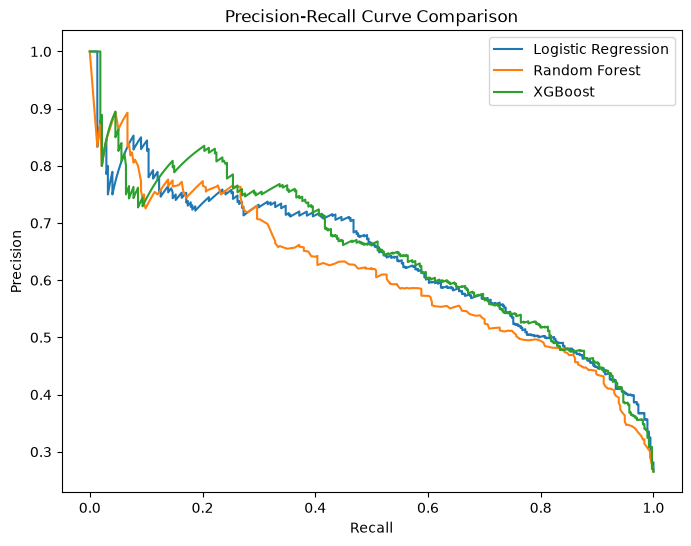

In [19]:
plt.figure(figsize=(8, 6))

plt.plot(
    recall_logistic,
    precision_logistic,
    label="Logistic Regression"
)

plt.plot(
    recall_rf,
    precision_rf,
    label="Random Forest"
)

plt.plot(
    recall_xgb,
    precision_xgb,
    label="XGBoost"
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curve Comparison")

plt.legend()

plt.show()

In [20]:
# 5-fold Stratified Cross-Validation

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [21]:
# Logistic Regression

logistic_cv = cross_val_score(
    logistic_model,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc"
)

print("Logistic Regression")
print("Fold scores:", logistic_cv)
print("Mean ROC-AUC:", logistic_cv.mean())
print("Std:", logistic_cv.std())

Logistic Regression
Fold scores: [0.84599228 0.82652521 0.84083418 0.85863304 0.85729942]
Mean ROC-AUC: 0.8458568275307441
Std: 0.011773880628956674


In [22]:
# Random Forest

rf_cv = cross_val_score(
    random_forest_model,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc"
)

print("Random Forest")
print("Fold scores:", rf_cv)
print("Mean ROC-AUC:", rf_cv.mean())
print("Std:", rf_cv.std())

Random Forest
Fold scores: [0.82505493 0.8104309  0.8343492  0.82521246 0.84057701]
Mean ROC-AUC: 0.8271249030804831
Std: 0.010195896436445978


In [23]:
# XGBoost

xgb_cv = cross_val_score(
    xgboost_model,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc"
)

print("XGBoost")
print("Fold scores:", xgb_cv)
print("Mean ROC-AUC:", xgb_cv.mean())
print("Std:", xgb_cv.std())

XGBoost
Fold scores: [0.83866108 0.83075429 0.84380907 0.85735261 0.85302884]
Mean ROC-AUC: 0.8447211765649854
Std: 0.009604177321698385


In [24]:
# Weighted Logistic Regression

weighted_logistic = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

start_time = time.time()

weighted_logistic.fit(
    X_train,
    y_train
)

weighted_logistic_training_time = time.time() - start_time

weighted_logistic_pred = weighted_logistic.predict(
    X_test
)

weighted_logistic_probability = weighted_logistic.predict_proba(
    X_test
)[:, 1]

weighted_logistic_metrics = calculate_metrics(
    "Weighted Logistic Regression",
    y_test,
    weighted_logistic_pred,
    weighted_logistic_probability
)

weighted_logistic_metrics

{'Model': 'Weighted Logistic Regression',
 'Accuracy': 0.7388218594748048,
 'Precision': 0.5051724137931034,
 'Recall': 0.7834224598930482,
 'F1': 0.6142557651991615,
 'ROC-AUC': 0.8432380066651165,
 'PR-AUC': 0.6397852509367605}

In [25]:
# Weighted Random Forest

weighted_rf = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

start_time = time.time()

weighted_rf.fit(
    X_train,
    y_train
)

weighted_rf_training_time = time.time() - start_time

weighted_rf_pred = weighted_rf.predict(
    X_test
)

weighted_rf_probability = weighted_rf.predict_proba(
    X_test
)[:, 1]

weighted_rf_metrics = calculate_metrics(
    "Weighted Random Forest",
    y_test,
    weighted_rf_pred,
    weighted_rf_probability
)

weighted_rf_metrics

{'Model': 'Weighted Random Forest',
 'Accuracy': 0.7693399574166075,
 'Precision': 0.5573770491803278,
 'Recall': 0.6363636363636364,
 'F1': 0.5942571785268415,
 'ROC-AUC': 0.8200483091787439,
 'PR-AUC': 0.6053390680381793}

In [27]:
# XGBoost class weighting

negative_count = (y_train == 0).sum()

positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

print("Negative:", negative_count)
print("Positive:", positive_count)
print("Scale Pos Weight:", scale_pos_weight)

Negative: 4139
Positive: 1495
Scale Pos Weight: 2.768561872909699


In [28]:
weighted_xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42
)

start_time = time.time()

weighted_xgb.fit(
    X_train,
    y_train
)

weighted_xgb_training_time = time.time() - start_time

weighted_xgb_pred = weighted_xgb.predict(
    X_test
)

weighted_xgb_probability = weighted_xgb.predict_proba(
    X_test
)[:, 1]

weighted_xgb_metrics = calculate_metrics(
    "Weighted XGBoost",
    y_test,
    weighted_xgb_pred,
    weighted_xgb_probability
)

weighted_xgb_metrics

{'Model': 'Weighted XGBoost',
 'Accuracy': 0.7537260468417317,
 'Precision': 0.5244122965641953,
 'Recall': 0.7754010695187166,
 'F1': 0.6256742179072277,
 'ROC-AUC': 0.8414606422279057,
 'PR-AUC': 0.6477890579036993}

In [29]:
class_weight_results = pd.DataFrame([
    logistic_metrics,
    weighted_logistic_metrics,
    rf_metrics,
    weighted_rf_metrics,
    xgb_metrics,
    weighted_xgb_metrics
])

class_weight_results

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.799148,0.656357,0.510695,0.574436,0.843362,0.639736
1,Weighted Logistic Regression,0.738822,0.505172,0.783422,0.614256,0.843238,0.639785
2,Random Forest,0.781405,0.605096,0.508021,0.552326,0.822318,0.611618
3,Weighted Random Forest,0.769340,0.557377,0.636364,0.594257,0.820048,0.605339
4,XGBoost,0.799148,0.653199,0.518717,0.578241,0.844127,0.650283
5,Weighted XGBoost,0.753726,0.524412,0.775401,0.625674,0.841461,0.647789


In [30]:
class_weight_results.sort_values(
    by="F1",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
5,Weighted XGBoost,0.753726,0.524412,0.775401,0.625674,0.841461,0.647789
1,Weighted Logistic Regression,0.738822,0.505172,0.783422,0.614256,0.843238,0.639785
3,Weighted Random Forest,0.769340,0.557377,0.636364,0.594257,0.820048,0.605339
4,XGBoost,0.799148,0.653199,0.518717,0.578241,0.844127,0.650283
0,Logistic Regression,0.799148,0.656357,0.510695,0.574436,0.843362,0.639736
2,Random Forest,0.781405,0.605096,0.508021,0.552326,0.822318,0.611618


In [31]:
# Hyper Parameter Tuning

rf_parameters = {
    "n_estimators": [100, 150, 200, 250],
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "class_weight": [None, "balanced", "balanced_subsample"]
}

In [32]:
rf_random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    param_distributions=rf_parameters,
    n_iter=10,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1
)

In [33]:
start_time = time.time()

rf_random_search.fit(
    X_train,
    y_train
)

rf_tuning_time = time.time() - start_time

print("Random Forest tuning time:", rf_tuning_time)

Random Forest tuning time: 38.870341539382935


In [34]:
print("Best parameters:")
print(rf_random_search.best_params_)

print()

print("Best CV ROC-AUC:")
print(rf_random_search.best_score_)

Best parameters:
{'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_depth': 5, 'class_weight': 'balanced_subsample'}

Best CV ROC-AUC:
0.845096670520687


In [35]:
# Evaluate tuned Random Forest

tuned_rf = rf_random_search.best_estimator_

tuned_rf_pred = tuned_rf.predict(
    X_test
)

tuned_rf_probability = tuned_rf.predict_proba(
    X_test
)[:, 1]

tuned_rf_metrics = calculate_metrics(
    "Tuned Random Forest",
    y_test,
    tuned_rf_pred,
    tuned_rf_probability
)

tuned_rf_metrics

{'Model': 'Tuned Random Forest',
 'Accuracy': 0.7572746628814763,
 'Precision': 0.5291970802919708,
 'Recall': 0.7754010695187166,
 'F1': 0.6290672451193059,
 'ROC-AUC': 0.8432444651114728,
 'PR-AUC': 0.6479405222150922}

In [36]:
# XGBoost tuning

xgb_parameters = {
    "n_estimators": [100, 150, 200, 250],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.8, 0.9, 1.0],
    "colsample_bytree": [0.8, 0.9, 1.0]
}

In [37]:
xgb_random_search = RandomizedSearchCV(
    estimator=XGBClassifier(
        eval_metric="logloss",
        random_state=42
    ),
    param_distributions=xgb_parameters,
    n_iter=10,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1
)

In [38]:
start_time = time.time()

xgb_random_search.fit(
    X_train,
    y_train
)

xgb_tuning_time = time.time() - start_time

print("XGBoost tuning time:", xgb_tuning_time)

XGBoost tuning time: 11.454581260681152


In [39]:
print("Best parameters:")
print(xgb_random_search.best_params_)

print()

print("Best CV ROC-AUC:")
print(xgb_random_search.best_score_)

Best parameters:
{'subsample': 0.8, 'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 1.0}

Best CV ROC-AUC:
0.8463680561868377


In [40]:
tuned_xgb = xgb_random_search.best_estimator_

tuned_xgb_pred = tuned_xgb.predict(
    X_test
)

tuned_xgb_probability = tuned_xgb.predict_proba(
    X_test
)[:, 1]

tuned_xgb_metrics = calculate_metrics(
    "Tuned XGBoost",
    y_test,
    tuned_xgb_pred,
    tuned_xgb_probability
)

tuned_xgb_metrics

{'Model': 'Tuned XGBoost',
 'Accuracy': 0.8034066713981547,
 'Precision': 0.6979591836734694,
 'Recall': 0.4572192513368984,
 'F1': 0.5525040387722132,
 'ROC-AUC': 0.8451858740861299,
 'PR-AUC': 0.6547729361511107}

In [41]:
# Feature Selection

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": tuned_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
12,MonthToMonthContract,0.175501
16,ServiceRiskIndicator,0.110022
1,tenure,0.075454
24,InternetService_Fiber optic,0.061606
15,NoOnlineSecurity,0.057917
39,Contract_Two year,0.053523
14,NoTechSupport,0.049043
9,IsFiberCustomer,0.045063
3,TotalCharges,0.039707
13,ElectronicCheck,0.035367


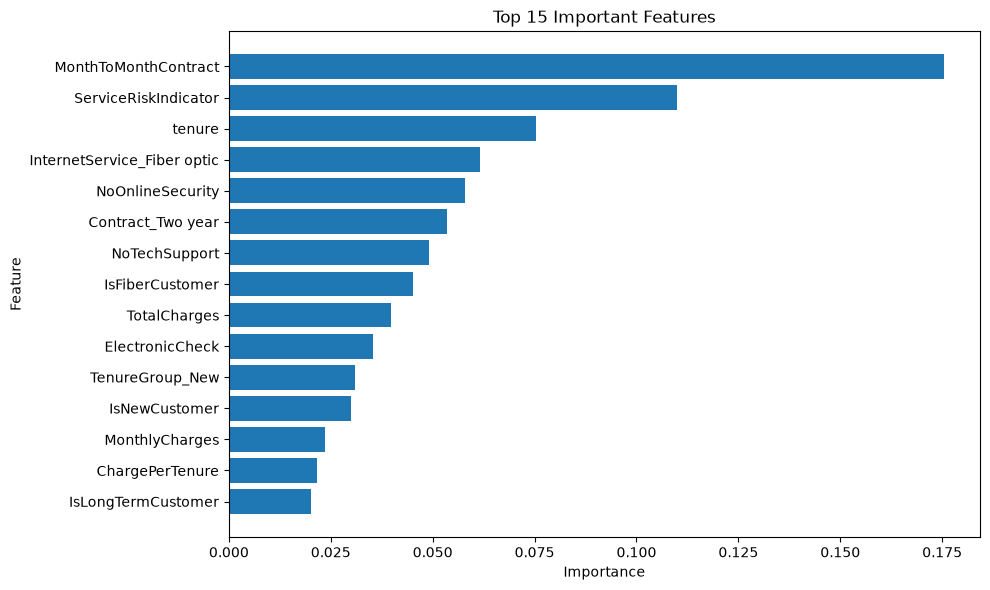

In [42]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance.head(15)["Feature"][::-1],
    feature_importance.head(15)["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Important Features")

plt.tight_layout()
plt.show()

In [43]:
# Selected important features based on the feature importance plot

selected_features = feature_importance.head(
    20
)["Feature"].tolist()

print("Number of selected features:", len(selected_features))

print()

print(selected_features)

Number of selected features: 20

['MonthToMonthContract', 'ServiceRiskIndicator', 'tenure', 'InternetService_Fiber optic', 'NoOnlineSecurity', 'Contract_Two year', 'NoTechSupport', 'IsFiberCustomer', 'TotalCharges', 'ElectronicCheck', 'TenureGroup_New', 'IsNewCustomer', 'MonthlyCharges', 'ChargePerTenure', 'IsLongTermCustomer', 'PaymentMethod_Electronic check', 'TenureGroup_Long-term', 'Contract_One year', 'TechSupport_No internet service', 'OnlineBackup_No internet service']


In [44]:
# Create selected-feature datasets

X_train_selected = X_train[
    selected_features
]

X_test_selected = X_test[
    selected_features
]

print("Original features:", X_train.shape[1])

print(
    "Selected features:",
    X_train_selected.shape[1]
)

Original features: 53
Selected features: 20


In [45]:
# Train tuned Random Forest with selected features

selected_rf = RandomForestClassifier(
    **rf_random_search.best_params_,
    random_state=42,
    n_jobs=-1
)

start_time = time.time()

selected_rf.fit(
    X_train_selected,
    y_train
)

selected_rf_training_time = time.time() - start_time

selected_rf_pred = selected_rf.predict(
    X_test_selected
)

selected_rf_probability = selected_rf.predict_proba(
    X_test_selected
)[:, 1]

selected_rf_metrics = calculate_metrics(
    "Tuned RF + Feature Selection",
    y_test,
    selected_rf_pred,
    selected_rf_probability
)

selected_rf_metrics

{'Model': 'Tuned RF + Feature Selection',
 'Accuracy': 0.7551454932576295,
 'Precision': 0.5259391771019678,
 'Recall': 0.786096256684492,
 'F1': 0.6302250803858521,
 'ROC-AUC': 0.8433775091064093,
 'PR-AUC': 0.6508046712032068}

In [46]:
# Probability threshold adjustment

threshold_30_pred = (
    tuned_rf_probability >= 0.30
).astype(int)

threshold_35_pred = (
    tuned_rf_probability >= 0.35
).astype(int)

threshold_40_pred = (
    tuned_rf_probability >= 0.40
).astype(int)

threshold_45_pred = (
    tuned_rf_probability >= 0.45
).astype(int)

threshold_50_pred = (
    tuned_rf_probability >= 0.50
).astype(int)

threshold_55_pred = (
    tuned_rf_probability >= 0.55
).astype(int)

threshold_60_pred = (
    tuned_rf_probability >= 0.60
).astype(int)

In [47]:
threshold_30_metrics = calculate_metrics(
    "Threshold 0.30",
    y_test,
    threshold_30_pred,
    tuned_rf_probability
)

threshold_35_metrics = calculate_metrics(
    "Threshold 0.35",
    y_test,
    threshold_35_pred,
    tuned_rf_probability
)

threshold_40_metrics = calculate_metrics(
    "Threshold 0.40",
    y_test,
    threshold_40_pred,
    tuned_rf_probability
)

threshold_45_metrics = calculate_metrics(
    "Threshold 0.45",
    y_test,
    threshold_45_pred,
    tuned_rf_probability
)

threshold_50_metrics = calculate_metrics(
    "Threshold 0.50",
    y_test,
    threshold_50_pred,
    tuned_rf_probability
)

threshold_55_metrics = calculate_metrics(
    "Threshold 0.55",
    y_test,
    threshold_55_pred,
    tuned_rf_probability
)

threshold_60_metrics = calculate_metrics(
    "Threshold 0.60",
    y_test,
    threshold_60_pred,
    tuned_rf_probability
)

In [48]:
threshold_results = pd.DataFrame([
    threshold_30_metrics,
    threshold_35_metrics,
    threshold_40_metrics,
    threshold_45_metrics,
    threshold_50_metrics,
    threshold_55_metrics,
    threshold_60_metrics
])

threshold_results

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Threshold 0.30,0.633073,0.414779,0.930481,0.573784,0.843244,0.647941
1,Threshold 0.35,0.668559,0.438896,0.893048,0.588546,0.843244,0.647941
2,Threshold 0.40,0.696238,0.460983,0.852941,0.598499,0.843244,0.647941
3,Threshold 0.45,0.729595,0.494364,0.820856,0.617085,0.843244,0.647941
4,Threshold 0.50,0.757275,0.529197,0.775401,0.629067,0.843244,0.647941
5,Threshold 0.55,0.772889,0.554435,0.735294,0.632184,0.843244,0.647941
6,Threshold 0.60,0.787083,0.583710,0.689840,0.632353,0.843244,0.647941


In [49]:
threshold_results[
    [
        "Model",
        "Precision",
        "Recall",
        "F1"
    ]
]

,Model,Precision,Recall,F1
0,Threshold 0.30,0.414779,0.930481,0.573784
1,Threshold 0.35,0.438896,0.893048,0.588546
2,Threshold 0.40,0.460983,0.852941,0.598499
3,Threshold 0.45,0.494364,0.820856,0.617085
4,Threshold 0.50,0.529197,0.775401,0.629067
5,Threshold 0.55,0.554435,0.735294,0.632184
6,Threshold 0.60,0.583710,0.689840,0.632353


In [50]:
# Final model comparison

final_comparison = pd.DataFrame([
    rf_metrics,
    weighted_rf_metrics,
    tuned_rf_metrics,
    selected_rf_metrics,
    xgb_metrics,
    weighted_xgb_metrics,
    tuned_xgb_metrics
])

final_comparison

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Random Forest,0.781405,0.605096,0.508021,0.552326,0.822318,0.611618
1,Weighted Random Forest,0.769340,0.557377,0.636364,0.594257,0.820048,0.605339
2,Tuned Random Forest,0.757275,0.529197,0.775401,0.629067,0.843244,0.647941
3,Tuned RF + Feature Selection,0.755145,0.525939,0.786096,0.630225,0.843378,0.650805
4,XGBoost,0.799148,0.653199,0.518717,0.578241,0.844127,0.650283
5,Weighted XGBoost,0.753726,0.524412,0.775401,0.625674,0.841461,0.647789
6,Tuned XGBoost,0.803407,0.697959,0.457219,0.552504,0.845186,0.654773


In [51]:
final_comparison = final_comparison.sort_values(
    by="F1",
    ascending=False
).reset_index(drop=True)

final_comparison

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Tuned RF + Feature Selection,0.755145,0.525939,0.786096,0.630225,0.843378,0.650805
1,Tuned Random Forest,0.757275,0.529197,0.775401,0.629067,0.843244,0.647941
2,Weighted XGBoost,0.753726,0.524412,0.775401,0.625674,0.841461,0.647789
3,Weighted Random Forest,0.769340,0.557377,0.636364,0.594257,0.820048,0.605339
4,XGBoost,0.799148,0.653199,0.518717,0.578241,0.844127,0.650283
5,Tuned XGBoost,0.803407,0.697959,0.457219,0.552504,0.845186,0.654773
6,Random Forest,0.781405,0.605096,0.508021,0.552326,0.822318,0.611618


In [52]:
final_comparison.sort_values(
    by="ROC-AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
5,Tuned XGBoost,0.803407,0.697959,0.457219,0.552504,0.845186,0.654773
4,XGBoost,0.799148,0.653199,0.518717,0.578241,0.844127,0.650283
0,Tuned RF + Feature Selection,0.755145,0.525939,0.786096,0.630225,0.843378,0.650805
1,Tuned Random Forest,0.757275,0.529197,0.775401,0.629067,0.843244,0.647941
2,Weighted XGBoost,0.753726,0.524412,0.775401,0.625674,0.841461,0.647789
6,Random Forest,0.781405,0.605096,0.508021,0.552326,0.822318,0.611618
3,Weighted Random Forest,0.769340,0.557377,0.636364,0.594257,0.820048,0.605339


In [53]:
# Final selected model

final_model = tuned_rf

final_model_name = "Tuned Random Forest"

final_threshold = 0.50

print("Final model:", final_model_name)
print("Final threshold:", final_threshold)

Final model: Tuned Random Forest
Final threshold: 0.5


In [54]:
joblib.dump(
    final_model,
    "../models/final_churn_model.pkl"
)

print("Final churn model saved.")

Final churn model saved.


In [55]:
joblib.dump(
    selected_features,
    "../models/selected_features.pkl"
)

print("Selected features saved.")

Selected features saved.


In [56]:
joblib.dump(
    final_threshold,
    "../models/churn_threshold.pkl"
)

print("Churn threshold saved.")

Churn threshold saved.


In [57]:
final_comparison.to_csv(
    "../data/processed/phase7_final_comparison.csv",
    index=False
)

threshold_results.to_csv(
    "../data/processed/phase7_threshold_comparison.csv",
    index=False
)

class_weight_results.to_csv(
    "../data/processed/phase7_class_weight_comparison.csv",
    index=False
)

print("Phase 7 results saved successfully.")

Phase 7 results saved successfully.
